# Project Report: S&P 500 Volatility Forecasting (GRU vs. GARCH)

## 1. Executive Summary
This project explores the forecasting of financial volatility for the S&P 500 index (^GSPC) using a Deep Learning approach (Gated Recurrent Units - GRU) compared against standard econometric benchmarks (Naive Baseline and GARCH(1,1)). 

Unlike traditional studies that approximate volatility using close-to-close returns, this project utilizes the **Garman-Klass (GK) Volatility Estimator**, a more efficient estimator that incorporates Open, High, Low, and Close prices to capture intraday variance.

## 2. Methodology

### 2.1 Data Acquisition & Preprocessing
*   **Data Source:** Yahoo Finance API (`yfinance`).
*   **Period:** 
    *   *Training/Test:* Jan 1, 2000 – Jan 1, 2024.
    *   *Out of Sample (OOS):* Jan 1, 2024 – Jan 1, 2025.
*   **Target Variable:** Garman-Klass Volatility. The code calculates this utilizing the formula:
    $$ \sigma_{GK}^{2} = 0.5 \ln\left(\frac{H_t}{L_t}\right)^2 - \left(2\ln(2) - 1\right)\ln\left(\frac{C_t}{O_t}\right)^2 $$
*   **Transformations:** 
    *   **Log-Transformation:** The raw volatility distribution is highly skewed. A Log transformation (`np.log`) is applied to normalize the distribution, making it more suitable for Neural Network training.
    *   **Feature Engineering:**
        *   `Diff_Volume`: Volume is differenced to ensure stationarity.
        *   `Neg_Ret`: Negative returns are isolated (clipped) to capture the "Leverage Effect" (volatility tends to increase more when prices drop).
*   **Stationarity Tests:** Augmented Dickey-Fuller (ADF) and KPSS tests are run to confirm the input features do not have unit roots.

### 2.2 Deep Learning Model (GRU)
*   **Architecture:**
    *   **Input Layer:** Sequence length of 21 days (approx. 1 trading month).
    *   **GRU Layer:** 64 Units with Tanh activation. GRUs are chosen over LSTMs for computational efficiency while maintaining memory of long-term dependencies.
    *   **Regularization:** Dropout (0.3) to prevent overfitting.
    *   **Dense Layers:** A hidden dense layer (32 units) followed by a linear output layer.
*   **Training Config:**
    *   Optimizer: Adam.
    *   Loss Function: Mean Squared Error (MSE).
    *   Callbacks: Early Stopping (patience 15) and ReduceLROnPlateau.

### 2.3 Benchmarks
*   **Naive Baseline:** Assumes volatility at time $t$ will be equal to volatility at $t-1$.
*   **GARCH(1,1):** The Generalized Autoregressive Conditional Heteroskedasticity model, widely considered the industry standard for volatility modeling. It is fitted on returns data using a rolling window approach relative to the split date.

## 3. Results and Performance

### 3.1 In-Sample Test Data (2019 - 2023)
The model was evaluated on the held-out test portion of the main dataset (20% split).
*   **Naive Baseline:** $R^2 \approx 0.42$
*   **GRU Model:** $R^2 \approx 0.62$
*   **Conclusion:** The GRU significantly outperformed the naive assumption, capturing non-linear dependencies in the volatility surface.

### 3.2 Out-of-Sample (OOS) Data (2024)
The model was tested on completely unseen data from 2024 to check for generalization.
*   **Naive Baseline:** $R^2 \approx -0.12$ (The baseline failed to predict trends, performing worse than a horizontal mean line).
*   **GRU Model:** $R^2 \approx 0.28$
*   **Conclusion:** While performance degraded (common in financial time series due to regime shifts), the GRU maintained a positive $R^2$, indicating it retained predictive power where the Naive model failed completely.

### 3.3 GRU vs. GARCH Comparison
The notebook concludes with a direct showdown between the Deep Learning approach and Econometrics.
*   **Observation:** The GARCH(1,1) model tends to be smoother and reacts slower to sudden spikes in Garman-Klass volatility.
*   **Outcome:** The GRU provided a tighter fit to the realized Garman-Klass volatility compared to the standard GARCH(1,1) implementation, likely due to its ability to ingest exogenous feature sets (Volume, Leverage effect specific features) which a standard Univariate GARCH does not use.

## 4. Key Technical Insights
1.  **Inverse Scaling Bug Fix:** The notebook demonstrates a critical step in time-series regression—predictions must be inverse-transformed from the `StandardScaler` space back to the original Log-Volatility space, and then exponentiated (`np.exp`) to get actual Volatility percentages for valid interpretation.
2.  **Lookback Window:** A 21-day lookback window was meaningful, likely because it aligns with the monthly trading cycle, allowing the RNN to "see" the volatility regime of the previous month.
3.  **Heteroskedasticity:** The Q-Q plots generated in the notebook confirm that even after log-transformation, financial data exhibits "fat tails" (extreme events happen more often than a Normal Distribution predicts), which is why the Deep Learning model (non-parametric) often adapts better than parametric models assuming normality.

In [10]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from arch import arch_model

import scipy.stats as stats

import utils.Features as util

import seaborn as sns
sns.set_style(style="whitegrid")

In [29]:
spy = yf.Ticker("SPY")

df = spy.history(period="max")

df[df.index == '2020-02-28']

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2020-02-28 00:00:00-05:00,264.554137,272.975519,261.658425,271.481842,384975800,0.0,0.0,0.0


In [14]:
data = yf.download("SPY", start="2000-01-01", end="2024-01-01")
data_OOS = yf.download("SPY", start="2024-01-01", end="2025-01-01")

C:\Users\yahya\AppData\Local\Temp\ipykernel_6980\2259006425.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
C:\Users\yahya\AppData\Local\Temp\ipykernel_6980\2259006425.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_OOS = yf.download("SPY", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [15]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2000-01-03,91.617020,93.388728,90.632737,93.388728,8164300
2000-01-04,88.034225,90.750845,87.965326,90.416189,8089800
2000-01-05,88.191734,89.156331,86.459397,88.152363,12177900
2000-01-06,86.774391,89.136670,86.774391,87.955531,6227200
2000-01-07,91.813988,91.813988,88.231195,88.388680,8066500


### Garman-Klass Volatility Formula
#### Definition
It incorporates the high, low, opening, and closing prices of an asset to provide a more accurate estimate of volatility compared to traditional methods that only use closing prices.
#### Theory
The Garman-Klass volatility estimator is based on the assumption that asset prices follow a geometric Brownian motion. It uses the high and low prices to capture intraday price movements, while the opening and closing prices help account for overnight price changes. By combining these four price points, the Garman-Klass formula aims to provide a more comprehensive measure of volatility that reflects both intraday and overnight risks. it is in theory 7 to 8 times more efficient than the close-to-close estimator (standard volatility).
#### Conclusion
It reacts much faster to market changes.
#### Formula:
$$
\sigma_{GK}^{2} = 0.5 \ln\left(\frac{H_t}{L_t}\right)^2 
- \left(2\ln(2) - 1\right)\ln\left(\frac{C_t}{O_t}\right)^2
$$

In [17]:
df = data.copy()
df_OOS = data_OOS.copy()
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df_OOS.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

<Axes: title={'center': 'S&P 500 Close Prices'}, xlabel='Date'>

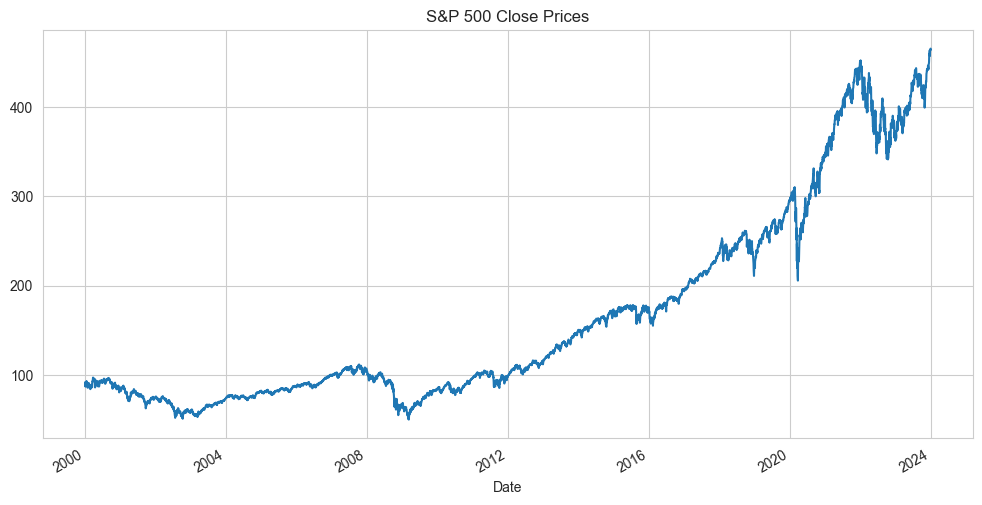

In [18]:
df.Close.plot(title="S&P 500 Close Prices", figsize=(12, 6))

In [5]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


<Axes: title={'center': 'Garman-Klass Volatility Estimator'}, xlabel='Date'>

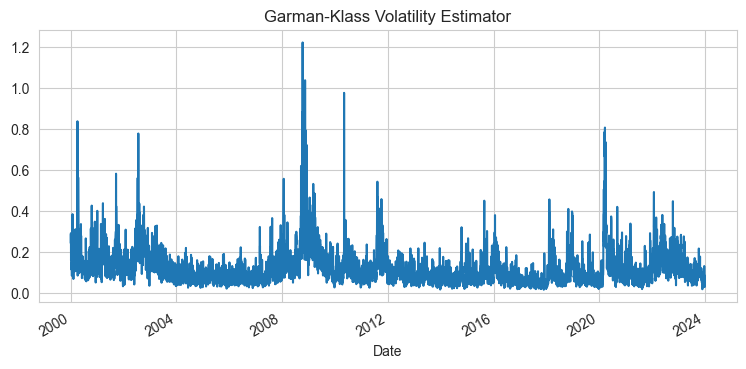

In [11]:
gk = util.calculate_garman_klass_volatility(df) * np.sqrt(252)
gk_OOS = util.calculate_garman_klass_volatility(df_OOS)

gk.plot(title='Garman-Klass Volatility Estimator', figsize=(9,4))

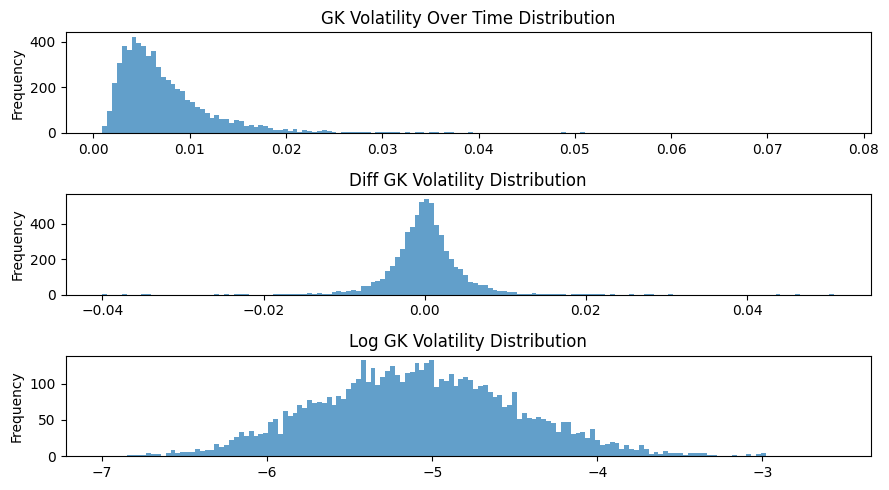

In [7]:
fig, ax = plt.subplots(3,1, figsize=(9,5))

gk.plot(kind='hist', title='GK Volatility Over Time Distribution', bins=150, alpha=0.7, ax=ax[0])
gk.diff().plot(kind='hist', title='Diff GK Volatility Distribution', bins=150, alpha=0.7, ax=ax[1])
np.log(gk).plot(kind='hist', title='Log GK Volatility Distribution', bins=150, alpha=0.7, ax=ax[2])
plt.tight_layout()
plt.show()


In [8]:
df['GK_Volatility'] = gk
df['LOG_GK_Volatility'] = np.log(gk)

df_OOS['GK_Volatility'] = gk_OOS
df_OOS['LOG_GK_Volatility'] = np.log(gk_OOS)

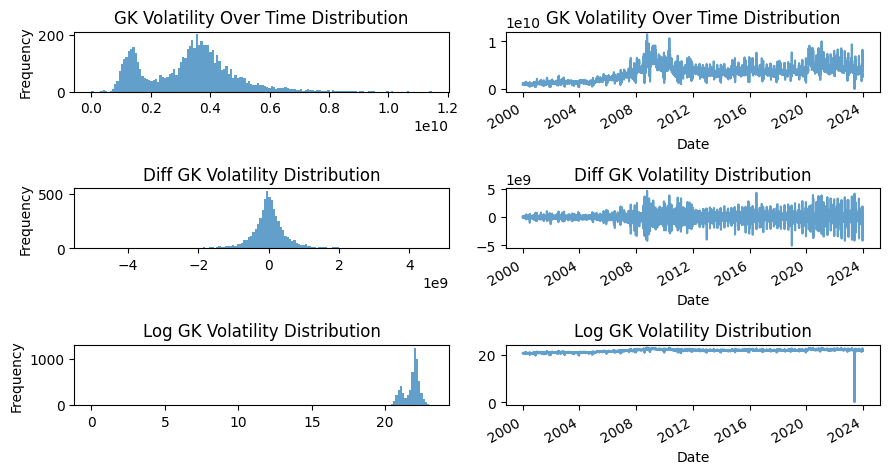

In [ ]:
fig, ax = plt.subplots(3,2, figsize=(9,5))

df["Volume"].plot(kind='hist', title='Volume Over Time Distribution', bins=150, alpha=0.7, ax=ax[0,0])
df["Volume"].diff().plot(kind='hist', title='Diff Volume Distribution', bins=150, alpha=0.7, ax=ax[1,0])
np.log(df["Volume"] + 1).plot(kind='hist', title='Log Volume Distribution', bins=150, alpha=0.7, ax=ax[2,0])


df["Volume"].plot(kind='line', title='Volume Over Time Distribution',alpha=0.7, ax=ax[0,1])
df["Volume"].diff().plot(kind='line', title='Diff Volume Distribution',alpha=0.7, ax=ax[1,1])
np.log(df["Volume"] + 1).plot(kind='line', title='Log Volume Distribution',alpha=0.7, ax=ax[2,1])
plt.tight_layout()
plt.show()


In [10]:
df['Diff_Volume'] = df['Volume'].diff()
df.dropna(inplace=True)

df_OOS['Diff_Volume'] = df_OOS['Volume'].diff()
df_OOS.dropna(inplace=True)

In [11]:
df['Neg_Ret'] = df['Close'].pct_change().clip(upper=0.0)
df['Neg_Ret'] = df['Neg_Ret'].fillna(0.0)


df_OOS['Neg_Ret'] = df_OOS['Close'].pct_change().clip(upper=0.0)
df_OOS['Neg_Ret'] = df_OOS['Neg_Ret'].fillna(0.0)


In [41]:
df_OOS['Close'].pct_change().clip(upper=0.0)

Date
2024-01-03         NaN
2024-01-04   -0.003428
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09   -0.001478
                ...   
2024-12-24    0.000000
2024-12-26   -0.000406
2024-12-27   -0.011056
2024-12-30   -0.010702
2024-12-31   -0.004285
Name: Close, Length: 251, dtype: float64

In [12]:
df.isna().sum()

Close                0
High                 0
Low                  0
Open                 0
Volume               0
GK_Volatility        0
LOG_GK_Volatility    0
Diff_Volume          0
Neg_Ret              0
dtype: int64

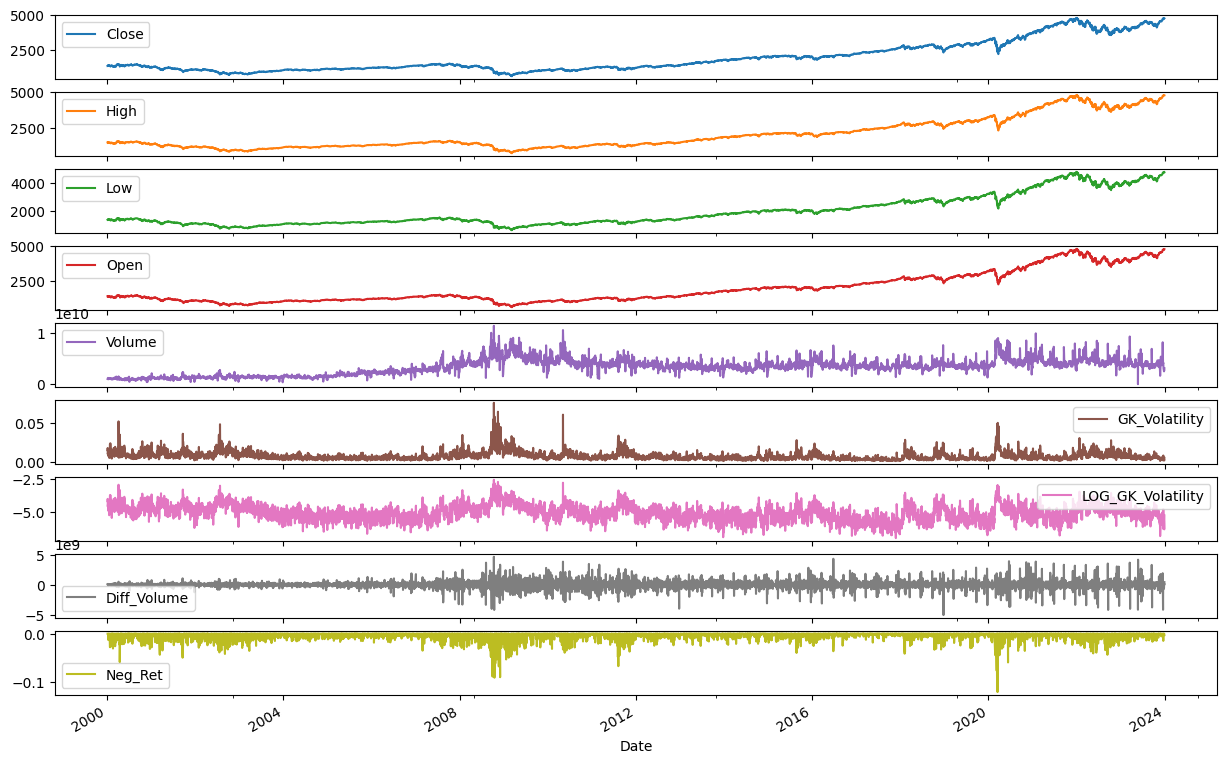

In [13]:
df.plot(subplots=True, figsize=(15,10))
plt.show()

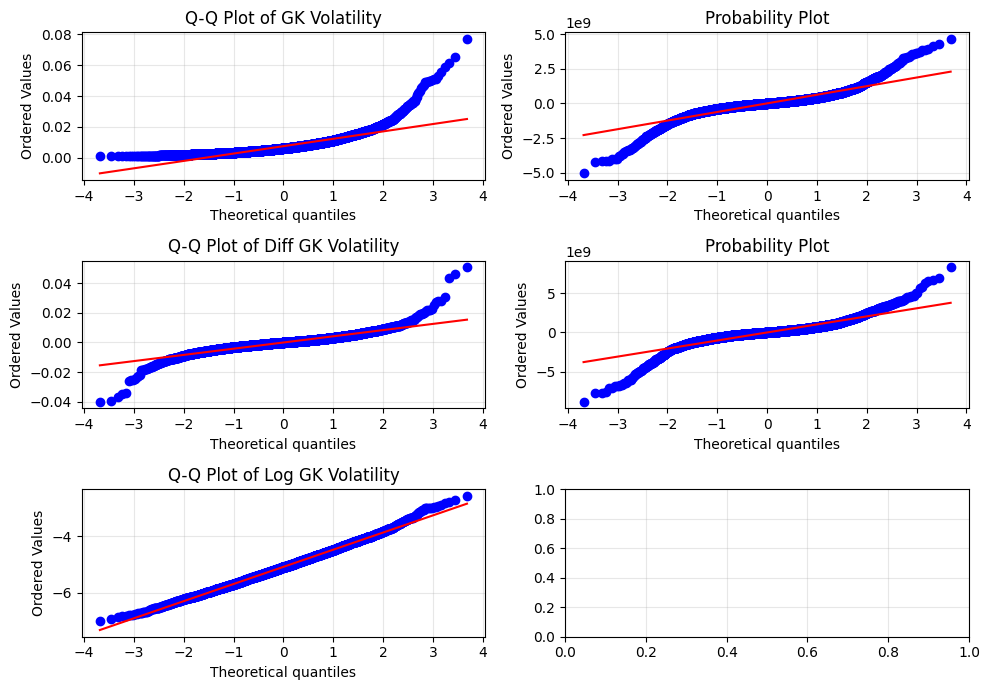

In [14]:
fig, ax = plt.subplots(3,2, figsize=(10, 7))

stats.probplot(df["GK_Volatility"], dist="norm", plot=ax[0,0])
stats.probplot((df["GK_Volatility"]).diff().dropna(), dist="norm", plot=ax[1, 0])
stats.probplot(np.log(df["GK_Volatility"]), dist="norm", plot=ax[2, 0])

ax[0,0].set_title("Q-Q Plot of GK Volatility")
ax[1,0].set_title("Q-Q Plot of Diff GK Volatility")
ax[2,0].set_title("Q-Q Plot of Log GK Volatility")

stats.probplot(df["Diff_Volume"].dropna(), dist="norm", plot=ax[0,1])
stats.probplot((df["Diff_Volume"]).diff().dropna(), dist="norm", plot=ax[1, 1])
# stats.probplot(np.log(df["Diff_Volume"].dropna() + 1), dist="norm", plot=ax[2, 1])

for a in ax.ravel():
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
for col in df.columns[:]:
    print(f"{col} - Mean: {df[col].mean()}, Std: {df[col].std()}")
    print("ADF Test:")
    result = adfuller(df[col])
    print(f"\tADF Statistic: {result[0]}")
    print(f"\tp-value: {result[1]}")
    print(f"\tUsed Lag: {result[2]}")
    print(f"\tnobs: {result[3]}")

Close - Mean: 1973.6724301711702, Std: 1061.4028260464104
ADF Test:
	ADF Statistic: 1.5344751866999333
	p-value: 0.997647052527666
	Used Lag: 32
	nobs: 6003
High - Mean: 1985.0393213938214, Std: 1066.4708392756954
ADF Test:
	ADF Statistic: 1.5247642039859268
	p-value: 0.9976133512950586
	Used Lag: 34
	nobs: 6001
Low - Mean: 1960.88088167164, Std: 1055.5978656274497
ADF Test:
	ADF Statistic: 1.417948081594245
	p-value: 0.9971941712188653
	Used Lag: 33
	nobs: 6002
Open - Mean: 1973.3857412470975, Std: 1061.1320321560654
ADF Test:
	ADF Statistic: 1.5429507733398513
	p-value: 0.9976759175429503
	Used Lag: 31
	nobs: 6004
Volume - Mean: 3327089133.5321403, Std: 1509723279.7087934
ADF Test:
	ADF Statistic: -3.0616783323135697
	p-value: 0.02952223820378465
	Used Lag: 32
	nobs: 6003
GK_Volatility - Mean: 0.007504713463742464, Std: 0.005522242998249243
ADF Test:
	ADF Statistic: -6.52248445561299
	p-value: 1.033881511872823e-08
	Used Lag: 32
	nobs: 6003
LOG_GK_Volatility - Mean: -5.08589970672466

In [16]:
for col in df.columns[:]:
    print(f"{col} - Mean: {df[col].mean()}, Std: {df[col].std()}")
    print("KPSS Test:")
    result = kpss(df[col])
    print(f"\tKPSS Statistic: {result[0]}")
    print(f"\tp-value: {result[1]}")
    print(f"\tUsed Lag: {result[2]}")
    print(f"\tnobs: {result[3]}")

Close - Mean: 1973.6724301711702, Std: 1061.4028260464104
KPSS Test:
	KPSS Statistic: 10.501531976929995
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
High - Mean: 1985.0393213938214, Std: 1066.4708392756954
KPSS Test:
	KPSS Statistic: 10.493500627718738
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Low - Mean: 1960.88088167164, Std: 1055.5978656274497
KPSS Test:
	KPSS Statistic: 10.505327772897628
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Open - Mean: 1973.3857412470975, Std: 1061.1320321560654
KPSS Test:
	KPSS Statistic: 10.49952591154559
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Volume - Mean: 3327089133.5321403, Std: 1509723279.7087934
KPSS Test:
	KPSS Statistic: 6.48963489620342
	p-value: 0.01
	Used Lag: 44
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
GK_Volatility - Mean: 0

C:\Users\yahya\AppData\Local\Temp\ipykernel_17668\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_17668\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_17668\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_17668\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned

In [17]:
def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: list[str] = ["Vol_Diff"],
    predict_col_index: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """Create sequences of data for time series forecasting.

    Args:
        data (pd.DataFrame): The input data containing features.
        lookback (int): The number of past timesteps to include in each input sequence.
        horizon (int): The number of future timesteps to predict.

    Returns:
        Tuple[np.ndarray]: The input sequences (X) and the corresponding targets (y).
    """
    X, y = [], []

    data_values = data[feature_cols].values

    for i in range(len(data) - lookback - horizon):
        window = data_values[i : i + lookback]
        future_window = data_values[i + lookback : i + lookback + horizon, predict_col_index]

        X.append(window)
        y.append(future_window)

    return np.array(X), np.array(y)


In [18]:
df

,Close,High,Low,Open,Volume,GK_Volatility,LOG_GK_Volatility,Diff_Volume,Neg_Ret
Date,,,,,,,,,
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,0.015182,-4.187676,77200000.0,0.000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.017995,-4.017640,76500000.0,0.000000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.009969,-4.608298,6800000.0,0.000000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,0.011618,-4.455200,132900000.0,0.000000
2000-01-10,1457.599976,1464.359985,1441.469971,1441.469971,1064800000,0.008733,-4.740591,-160400000.0,0.000000
...,...,...,...,...,...,...,...,...,...
2023-12-22,4754.629883,4772.939941,4736.770020,4753.919922,3046770000,0.005378,-5.225411,-384410000.0,0.000000
2023-12-26,4774.750000,4784.720215,4758.450195,4758.859863,2513910000,0.003296,-5.715083,-532860000.0,0.000000
2023-12-27,4781.580078,4785.390137,4768.899902,4773.450195,2748450000,0.002200,-6.119380,234540000.0,0.000000


In [19]:
HORIZON = 1
LOOKBACK = 21
feature_cols = ['LOG_GK_Volatility', "Diff_Volume", "Neg_Ret"]

X_raw, y_raw = create_sequences(df, lookback=LOOKBACK, horizon=HORIZON, feature_cols=feature_cols, predict_col_index=0)
X_OOS, y_OOS = create_sequences(df_OOS, lookback=LOOKBACK, horizon=HORIZON, feature_cols=feature_cols, predict_col_index=0)

print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

print("=" * 60, f"Out of scope Data", "=" * 60, sep="\n")
print(f"X2 shape: {X_OOS.shape}  (Samples, Timesteps, Features)")
print(f"y2 shape: {y_OOS.shape}  (Samples, Horizon)")

X shape: (6014, 21, 3)  (Samples, Timesteps, Features)
y shape: (6014, 1)  (Samples, Horizon)
Out of scope Data
X2 shape: (229, 21, 3)  (Samples, Timesteps, Features)
y2 shape: (229, 1)  (Samples, Horizon)


In [20]:
n_sep = int(0.8 * X_raw.shape[0])

X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

# X_scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
# y_scaler.fit(y_train.reshape(-1, y_train.shape[-1]))

X_train_scaled = X_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(4811, 21, 3), y=(4811, 1)
Test set: X=(1203, 21, 3), y=(1203, 1)
Scaled Data:
Training set: X=(4811, 21, 3), y=(4811, 1)
Test set: X=(1203, 21, 3), y=(1203, 1)


In [21]:
X_OOS_scaled = X_scaler.transform(
    X_OOS.reshape(-1, X_OOS.shape[-1])
).reshape(X_OOS.shape)

y_OOS_scaled = y_scaler.transform(
    y_OOS.reshape(-1, y_OOS.shape[-1])
).reshape(y_OOS.shape)

print("Out of Scope Data shapes:")
print("X_OOS:", X_OOS_scaled.shape)
print("y_OOS_scaled:", y_OOS_scaled.shape)

Out of Scope Data shapes:
X_OOS: (229, 21, 3)
y_OOS_scaled: (229, 1)


In [22]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (21, 3)
Output size: 1


In [23]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

In [25]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4438 - mae: 0.5300 - val_loss: 0.4452 - val_mae: 0.5302 - learning_rate: 0.0010
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4172 - mae: 0.5132 - val_loss: 0.4469 - val_mae: 0.5300 - learning_rate: 0.0010
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4132 - mae: 0.5109 - val_loss: 0.4654 - val_mae: 0.5373 - learning_rate: 0.0010
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4127 - mae: 0.5122 - val_loss: 0.4412 - val_mae: 0.5254 - learning_rate: 0.0010
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4061 - mae: 0.5082 - val_loss: 0.4523 - val_mae: 0.5317 - learning_rate: 0.0010
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4070 - mae: 0.5099 - val_loss: 0.4445 - val_mae: 0.5268 - learning_rate: 0.0010
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4051 - mae: 0.5074 - val_loss: 0.4402 - val_mae: 0.5238 - learning_rate: 0

In [26]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_test_scaled.shape)


y_pred_df = pd.DataFrame(
    y_pred[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Predicted_LOG_GK_Volatility"]
)
y_true_df = pd.DataFrame(
    y_true[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Actual_LOG_GK_Volatility"]
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


<Figure size 1400x600 with 0 Axes>

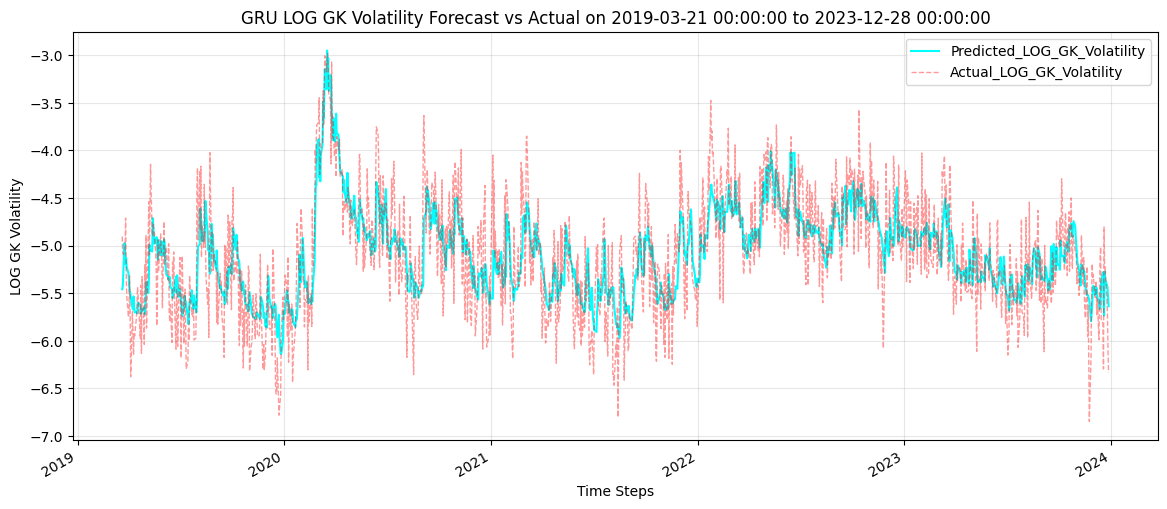

Sample 10 Actual GK Vol:    [-4.90385093 -5.09043623 -5.07687043 -5.05630208 -4.71155786]...
Sample 10 Predicted GK Vol: [-5.458202 -5.424226 -4.974494 -5.061587 -5.196442]...


In [27]:
plt.figure(figsize=(14, 6))

limit = 2000

fig, ax = plt.subplots(figsize=(14, 6))
y_pred_df.plot(ax=ax, color="cyan", legend=True)
y_true_df.plot(ax=ax, color="red", linewidth=1, linestyle="--", legend=True, alpha=0.4)

plt.title(
    f"GRU LOG GK Volatility Forecast vs Actual on {y_pred_df.index[0]} to {y_pred_df.index[-1]}"
)
plt.xlabel("Time Steps")
plt.ylabel("LOG GK Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sample 10 Actual GK Vol:    {y_test[:5,0]}...")
print(f"Sample 10 Predicted GK Vol: {y_pred[:5,0]}...")

plt.show()

### Metrics on LOG GK Volatility Prediction

In [28]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true_df[1:]["Actual_LOG_GK_Volatility"], y_true_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true_df[1:]["Actual_LOG_GK_Volatility"], y_true_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
naive_r2 = r2_score(y_true_df[1:]["Actual_LOG_GK_Volatility"], y_true_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true_df["Actual_LOG_GK_Volatility"], y_pred_df["Predicted_LOG_GK_Volatility"])
mae = mean_absolute_error(y_true_df["Actual_LOG_GK_Volatility"], y_pred_df["Predicted_LOG_GK_Volatility"])
r2 = r2_score(y_true_df["Actual_LOG_GK_Volatility"], y_pred_df["Predicted_LOG_GK_Volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("-" * 40)
print("Absolute differences between Naive Baseline and Model (10 decimal places):")
print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2019-03-21 00:00:00 to 2023-12-28 00:00:00 Data
Naive Baseline RMSE: 0.4969135053945801
Naive Baseline MAE: 0.3926886999570181
Naive Baseline R²: 0.3353495746465901
----------------------------------------
Model RMSE: 0.40316082154625554
Model MAE: 0.31829549093054044
Model R²: 0.5621558128913283
----------------------------------------
Absolute differences between Naive Baseline and Model (10 decimal places):
MSE: 0.0937526838
MAE: 0.0743932090
R²: 0.2268062382


### Going back to original GK volatility calculation

In [30]:
y_true_df["Actual_GK_Volatility"] = np.exp(y_true_df["Actual_LOG_GK_Volatility"])
y_pred_df["Predicted_GK_Volatility"] = np.exp(y_pred_df["Predicted_LOG_GK_Volatility"])

### Metrics on GK Volatility Prediction

In [31]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true_df[1:]["Actual_GK_Volatility"], y_true_df["Actual_GK_Volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true_df[1:]["Actual_GK_Volatility"], y_true_df["Actual_GK_Volatility"].shift(1).dropna())
naive_r2 = r2_score(y_true_df[1:]["Actual_GK_Volatility"], y_true_df["Actual_GK_Volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true_df["Actual_GK_Volatility"], y_pred_df["Predicted_GK_Volatility"])
mae = mean_absolute_error(y_true_df["Actual_GK_Volatility"], y_pred_df["Predicted_GK_Volatility"])
r2 = r2_score(y_true_df["Actual_GK_Volatility"], y_pred_df["Predicted_GK_Volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("-" * 40)
print("Absolute differences between Naive Baseline and Model (10 decimal places):")
print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2019-03-21 00:00:00 to 2023-12-28 00:00:00 Data
Naive Baseline RMSE: 0.004158618129123349
Naive Baseline MAE: 0.002864107169110461
Naive Baseline R²: 0.42162179614215833
----------------------------------------
Model RMSE: 0.003344310573456246
Model MAE: 0.0022498145425458114
Model R²: 0.6256412542160052
----------------------------------------
Absolute differences between Naive Baseline and Model (10 decimal places):
MSE: 0.0008143076
MAE: 0.0006142926
R²: 0.2040194581


In [ ]:
# ============================================================
# Evaluating on 2019-03-21 00:00:00 to 2023-12-28 00:00:00 Data
# ============================================================
# Naive Baseline RMSE: 0.004158618129123349
# Naive Baseline MAE: 0.002864107169110461
# Naive Baseline R²: 0.42162179614215833
# ----------------------------------------
# Model RMSE: 0.003344310573456246
# Model MAE: 0.0022498145425458114
# Model R²: 0.6256412542160052
# ----------------------------------------
# Absolute differences between Naive Baseline and Model (10 decimal places):
# MSE: 0.0008143076
# MAE: 0.0006142926
# R²: 0.2040194581

## Testing on out-of-sample data

In [33]:
y_OOS_pred: np.ndarray = model.predict(X_OOS_scaled)


y_OOS_pred = y_scaler.inverse_transform(
    y_OOS_pred.reshape(-1, y_OOS_scaled.shape[-1])
).reshape(y_OOS_pred.shape)

# y_true = y_OOS_scaled

y_OOS_pred_df = pd.DataFrame(
    y_OOS_pred[:, 0], index=df_OOS.index[LOOKBACK : -HORIZON], columns=["Predicted_LOG_GK_Volatility"]
)
y_OOS_df = pd.DataFrame(
    y_OOS[:, 0], index=df_OOS.index[LOOKBACK : -HORIZON], columns=["Actual_LOG_GK_Volatility"]
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


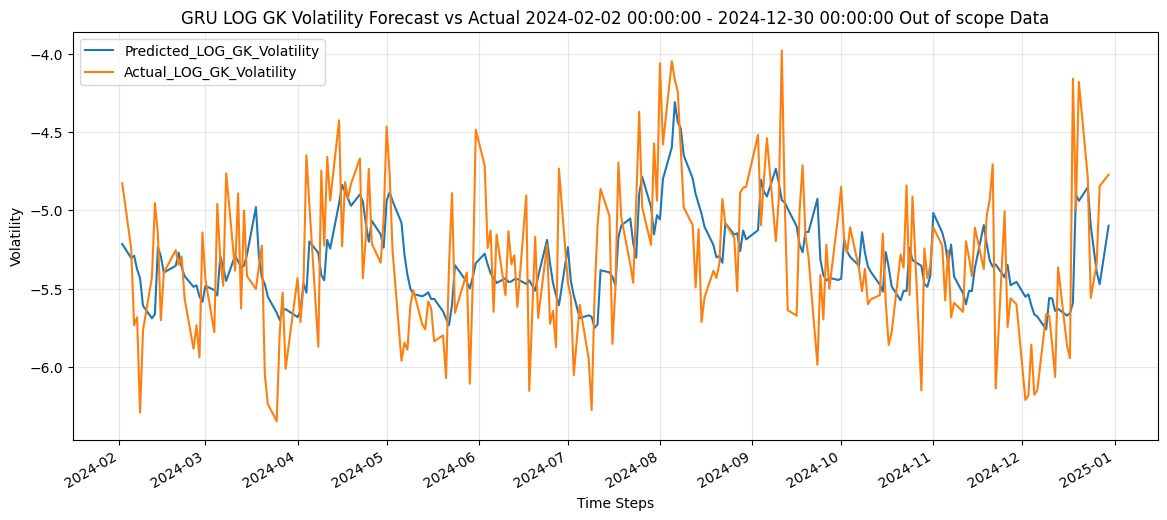

In [34]:
fig, ax = plt.subplots(figsize=(14, 6))

y_OOS_pred_df[["Predicted_LOG_GK_Volatility"]].plot(ax=ax)
y_OOS_df[["Actual_LOG_GK_Volatility"]].plot(ax=ax)

plt.title(f"GRU LOG GK Volatility Forecast vs Actual {y_OOS_df.index[0]} - {y_OOS_df.index[-1]} Out of scope Data")
plt.xlabel("Time Steps")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [35]:
print("=" * 60, f"Evaluating on {y_OOS_df.index[0]} to {y_OOS_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_OOS_df[1:]["Actual_LOG_GK_Volatility"], y_OOS_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_OOS_df[1:]["Actual_LOG_GK_Volatility"], y_OOS_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
naive_r2 = r2_score(y_OOS_df[1:]["Actual_LOG_GK_Volatility"], y_OOS_df["Actual_LOG_GK_Volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_OOS_df["Actual_LOG_GK_Volatility"], y_OOS_pred_df["Predicted_LOG_GK_Volatility"])
mae = mean_absolute_error(y_OOS_df["Actual_LOG_GK_Volatility"], y_OOS_pred_df["Predicted_LOG_GK_Volatility"])
r2 = r2_score(y_OOS_df["Actual_LOG_GK_Volatility"], y_OOS_pred_df["Predicted_LOG_GK_Volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("-" * 40)
print("Absolute differences between Naive Baseline and Model (10 decimal places):")
print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2024-02-02 00:00:00 to 2024-12-30 00:00:00 Data (Out of scope)
Naive Baseline RMSE: 0.49438615153958865
Naive Baseline MAE: 0.398926471829809
Naive Baseline R²: -0.098102132902123
----------------------------------------
Model RMSE: 0.39867597284941975
Model MAE: 0.3180288181218577
Model R²: 0.286159073445134
----------------------------------------
Absolute differences between Naive Baseline and Model (10 decimal places):
MSE: 0.0957101787
MAE: 0.0808976537
R²: 0.3842612063


### Computing the predicted and actual GK volatility values

In [37]:
y_OOS_df["Actual_GK_Volatility"] = np.exp(y_OOS_df["Actual_LOG_GK_Volatility"])
y_OOS_pred_df["Predicted_GK_Volatility"] = np.exp(y_OOS_pred_df["Predicted_LOG_GK_Volatility"])

In [38]:
print("=" * 60, f"Evaluating on {y_OOS_df.index[0]} to {y_OOS_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_OOS_df[1:]["Actual_GK_Volatility"], y_OOS_df["Actual_GK_Volatility"].shift(1).dropna())
naive_mae = mean_absolute_error(y_OOS_df[1:]["Actual_GK_Volatility"], y_OOS_df["Actual_GK_Volatility"].shift(1).dropna())
naive_r2 = r2_score(y_OOS_df[1:]["Actual_GK_Volatility"], y_OOS_df["Actual_GK_Volatility"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_OOS_df["Actual_GK_Volatility"], y_OOS_pred_df["Predicted_GK_Volatility"])
mae = mean_absolute_error(y_OOS_df["Actual_GK_Volatility"], y_OOS_pred_df["Predicted_GK_Volatility"])
r2 = r2_score(y_OOS_df["Actual_GK_Volatility"], y_OOS_pred_df["Predicted_GK_Volatility"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

print("-" * 40)
print("Absolute differences between Naive Baseline and Model (10 decimal places):")
print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2024-02-02 00:00:00 to 2024-12-30 00:00:00 Data (Out of scope)
Naive Baseline RMSE: 0.003104071039246156
Naive Baseline MAE: 0.0022522719977817614
Naive Baseline R²: -0.1290642889611493
----------------------------------------
Model RMSE: 0.002470487383790202
Model MAE: 0.0017254681029173085
Model R²: 0.2839670461240311
----------------------------------------
Absolute differences between Naive Baseline and Model (10 decimal places):
MSE: 0.0006335837
MAE: 0.0005268039
R²: 0.4130313351


In [ ]:
# ============================================================
# Evaluating on 2024-02-02 00:00:00 to 2024-12-30 00:00:00 Data (Out of scope)
# ============================================================
# Naive Baseline RMSE: 0.003104071039246156
# Naive Baseline MAE: 0.0022522719977817614
# Naive Baseline R²: -0.1290642889611493
# ----------------------------------------
# Model RMSE: 0.002470487383790202
# Model MAE: 0.0017254681029173085
# Model R²: 0.2839670461240311
# ----------------------------------------
# Absolute differences between Naive Baseline and Model (10 decimal places):
# MSE: 0.0006335837
# MAE: 0.0005268039
# R²: 0.4130313351

***
## <center>GARCH Model</center>
***

In [54]:
# 1. SETUP DATA FOR GARCH
# GARCH models work best on Returns.
# 'Rescale' is often needed: GARCH converges better if returns are * 100 (percentage).
returns_series = df['Close'].pct_change().dropna() * 100 

# Define the exact split point used in your GRU
# (Assuming 'n_sep' and 'LOOKBACK' variables are from your previous code)
# We need to ensure the Test sets align by Date Index.
split_date = df.index[n_sep + LOOKBACK] 

print(f"Training data up to: {split_date}")
print(returns_series.shape)

Training data up to: 2019-03-21 00:00:00
(6035,)


In [58]:
# 2. TRAIN GARCH
# We use a Rolling Window approach to simulate real-time forecasting.
# This is computationally expensive but the most accurate comparison to a GRU.
# For a faster "approximate" comparison, we fit once on train and forecast the rest.
# Here is the standard "Fixed Window" approach (Fit on Train, Forecast Test):

am = arch_model(returns_series, vol='Garch', p=1, o=0, q=1, dist='Normal')

# We split the data manually for the fit to ensure no leakage
train_returns = returns_series.loc[:split_date]
test_returns = returns_series.loc[split_date:]

# Fit only on TRAINING data
res = am.fit(last_obs=split_date, disp=True)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 16765408189.81478
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1208915516.3081
Iteration:      3,   Func. Count:     22,   Neg. LLF: 9561.615974733979
Iteration:      4,   Func. Count:     29,   Neg. LLF: 6698.512805158107
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6632.088296236913
Iteration:      6,   Func. Count:     41,   Neg. LLF: 6833.218023072413
Iteration:      7,   Func. Count:     47,   Neg. LLF: 6603.696840627876
Iteration:      8,   Func. Count:     53,   Neg. LLF: 6594.434700353695
Iteration:      9,   Func. Count:     58,   Neg. LLF: 6594.386401934989
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6594.386056707943
Iteration:     11,   Func. Count:     68,   Neg. LLF: 6594.386047653274
Iteration:     12,   Func. Count:     72,   Neg. LLF: 6594.386047654975
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6594.386047653274
            Iterations: 12
   

In [64]:
# 3. FORECAST
# We use the model parameters fitted on Train data to forecast the Test data.
# 'horizon=1' means we predict the next day's volatility.
forecasts = res.forecast(start=split_date, reindex=False)

# Extract Conditional Volatility (Sigma)
# Note: The output is Variance, so we take sqrt.
# Also divide by 100 to get back to decimal scale (since we multiplied by 100 earlier)
garch_pred_vol = np.sqrt(forecasts.variance[split_date:]) / 100

# Align indices exactly with your GRU "y_true_df"
# We align the GARCH predictions to the "Actual GK" dataframe you created for the GRU
common_index = y_true_df.index.intersection(garch_pred_vol.index)

# Filter both to the common index
garch_pred_final = garch_pred_vol.loc[common_index]
# This assumes 'y_true_df' contains the un-logged Actual GK Volatility
actual_gk_final = y_true_df.loc[common_index, "Actual_GK_Volatility"] 
gru_pred_final = y_pred_df.loc[common_index, "Predicted_GK_Volatility"]

GROUND-TO-GROUND COMPARISON
--- GRU (Your Model) Results ---
RMSE: 0.003344
MAE:  0.002250
R²:   0.625641
------------------------------
--- GARCH(1,1) Baseline Results ---
RMSE: 0.006108
MAE:  0.004479
R²:   -0.248594


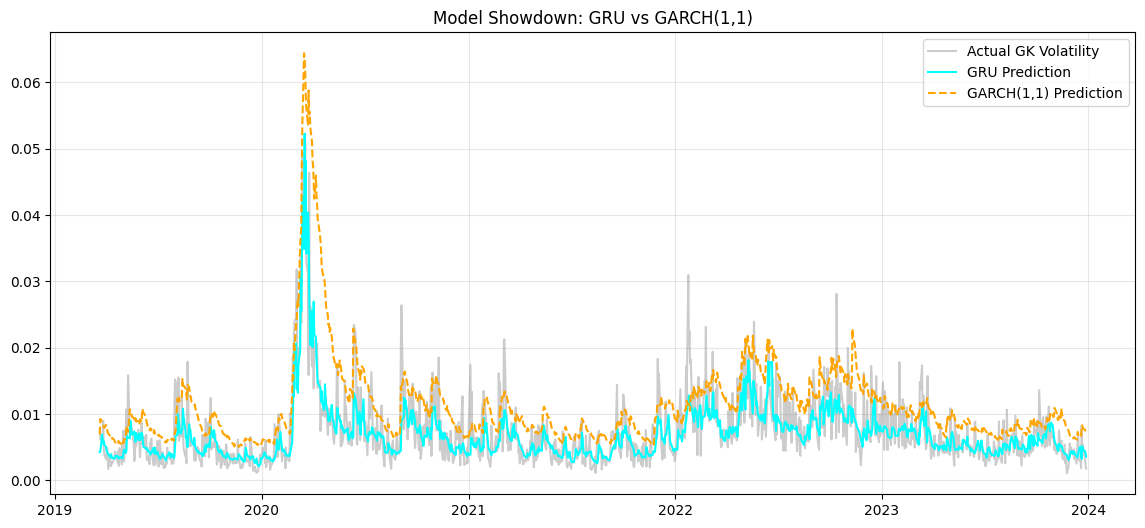

In [70]:
# 4. METRICS & COMPARISON
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Results ---")
    print(f"RMSE: {np.sqrt(mse):.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"R²:   {r2:.6f}")
    return np.sqrt(mse), mae, r2

print("="*30)
print("GROUND-TO-GROUND COMPARISON")
print("="*30)

# Evaluate GRU
evaluate_model(actual_gk_final, gru_pred_final, "GRU (Your Model)")

print("-" * 30)

# Evaluate GARCH
# Note: GARCH predicts 'h_t', column name is usually 'h.1'
evaluate_model(actual_gk_final, garch_pred_final['h.1'], "GARCH(1,1) Baseline")

# %%
# 5. VISUALIZATION
plt.figure(figsize=(14, 6))
plt.plot(actual_gk_final.index, actual_gk_final, color='gray', alpha=0.4, label='Actual GK Volatility')
plt.plot(gru_pred_final.index, gru_pred_final, color='cyan', label='GRU Prediction')
plt.plot(garch_pred_final.index, garch_pred_final['h.1'], color='orange', linestyle='--', label='GARCH(1,1) Prediction')

plt.title("Model Showdown: GRU vs GARCH(1,1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()